In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
data=pd.read_csv("/Users/aja/Desktop/uni/datagath/endterm/1st/taxi_trip_pricing.csv")

In [8]:
data

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [36]:
data.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [54]:
cleaned=data.dropna()
cleaned

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
5,8.64,Afternoon,Weekend,2.0,Medium,Clear,2.55,1.71,0.48,89.33,60.2028
12,41.79,Night,Weekend,3.0,High,Clear,4.60,1.77,0.11,86.95,88.1328
14,9.91,Evening,Weekday,2.0,High,Clear,2.32,1.26,0.34,41.72,28.9914
...,...,...,...,...,...,...,...,...,...,...,...
990,40.17,Evening,Weekday,3.0,Low,Clear,3.81,0.66,0.42,62.66,56.6394
992,14.34,Afternoon,Weekday,1.0,Medium,Clear,3.23,1.01,0.29,45.07,30.7837
994,18.69,Evening,Weekday,3.0,Medium,Clear,4.90,1.79,0.17,79.41,51.8548
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049


In [126]:
ccleaned=cleaned.drop(columns=['Base_Fare','Per_Km_Rate', 'Per_Minute_Rate'])
ccleaned

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,53.82,36.2624
2,36.87,Evening,Weekend,1.0,High,Clear,37.27,52.9032
5,8.64,Afternoon,Weekend,2.0,Medium,Clear,89.33,60.2028
12,41.79,Night,Weekend,3.0,High,Clear,86.95,88.1328
14,9.91,Evening,Weekday,2.0,High,Clear,41.72,28.9914
...,...,...,...,...,...,...,...,...
990,40.17,Evening,Weekday,3.0,Low,Clear,62.66,56.6394
992,14.34,Afternoon,Weekday,1.0,Medium,Clear,45.07,30.7837
994,18.69,Evening,Weekday,3.0,Medium,Clear,79.41,51.8548
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,58.39,34.4049


In [128]:
ccleaned.duplicated().sum()

0

In [60]:
mean_time=ccleaned['Trip_Duration_Minutes'].mean()
print(mean_time)

61.825088967971524


In [62]:
mean=ccleaned['Trip_Distance_km'].mean()
print(mean)

27.77294090950703


In [64]:
min_distance=ccleaned['Trip_Distance_km'].min()
max_distance=ccleaned['Trip_Distance_km'].max()
print(min_distance)
print(max_distance)

1.27
146.0670471598387


In [130]:
max_price=ccleaned['Trip_Price'].max()
print(max_price)

332.0436886774302


In [68]:
min_price=ccleaned['Trip_Price'].min()
print(min_price)

6.1269


<Axes: xlabel='Time_of_Day'>

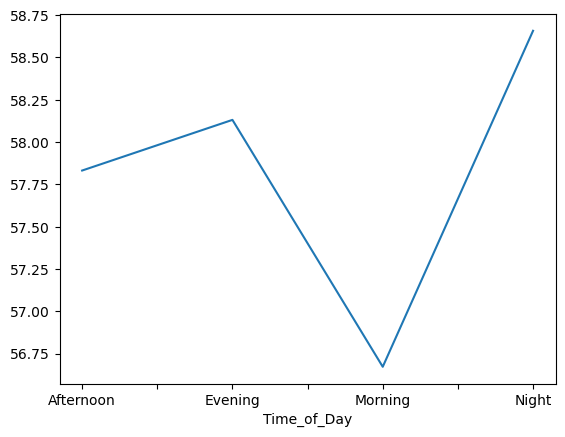

In [132]:
ccleaned.groupby('Time_of_Day')['Trip_Price'].mean().plot(kind='line')

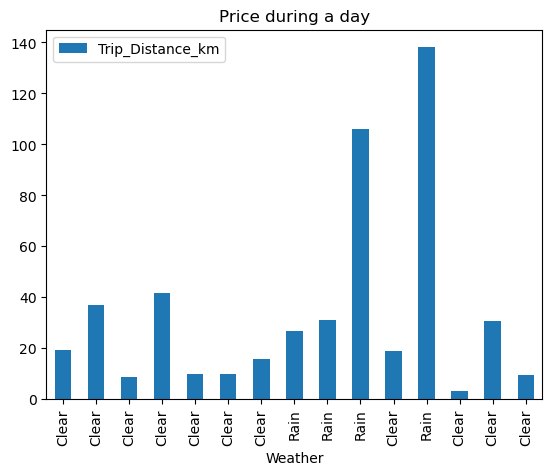

In [134]:
top=ccleaned.head(15)
top.plot(kind='bar', x='Weather', y='Trip_Distance_km', title='Price during a day')
plt.show()

<Axes: xlabel='Traffic_Conditions'>

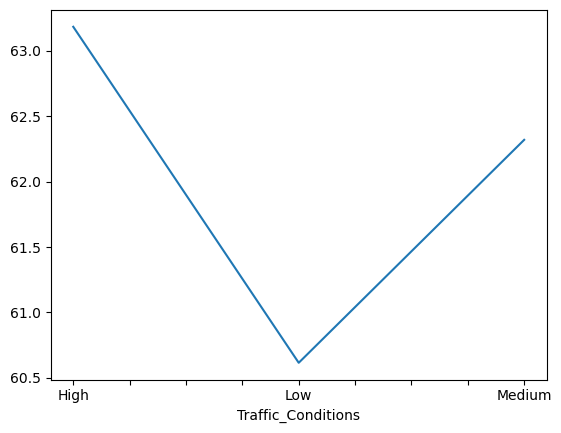

In [136]:
ccleaned.groupby('Traffic_Conditions')['Trip_Duration_Minutes'].mean().plot(kind='line')

In [138]:
less_trip=ccleaned[cleaned['Trip_Distance_km']>mean] 
less_trip

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Trip_Duration_Minutes,Trip_Price
2,36.870000,Evening,Weekend,1.0,High,Clear,37.27,52.903200
12,41.790000,Night,Weekend,3.0,High,Clear,86.95,88.132800
20,30.980000,Afternoon,Weekend,1.0,Low,Rain,57.02,44.778200
22,105.943550,Night,Weekend,2.0,Low,Rain,23.03,201.869509
27,138.098328,Evening,Weekend,4.0,Medium,Rain,94.86,280.877302
...,...,...,...,...,...,...,...,...
984,36.680000,Morning,Weekday,4.0,Low,Clear,108.41,85.574700
986,34.730000,Evening,Weekday,4.0,Low,Clear,5.65,44.885900
989,41.140000,Evening,Weekend,3.0,Medium,Rain,46.78,82.442000
990,40.170000,Evening,Weekday,3.0,Low,Clear,62.66,56.639400


In [140]:
pricy=ccleaned[cleaned['Trip_Price']>150]
pricy

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Trip_Duration_Minutes,Trip_Price
22,105.943550,Night,Weekend,2.0,Low,Rain,23.03,201.869509
27,138.098328,Evening,Weekend,4.0,Medium,Rain,94.86,280.877302
64,146.067047,Afternoon,Weekday,2.0,Medium,Clear,60.81,320.958664
108,112.830958,Afternoon,Weekday,2.0,High,Snow,78.63,233.008285
110,102.747556,Evening,Weekday,2.0,Medium,Clear,53.09,274.535087
141,109.616082,Afternoon,Weekday,4.0,High,Clear,53.88,327.217665
225,130.809001,Afternoon,Weekday,1.0,High,Clear,88.31,328.871769
267,116.196064,Afternoon,Weekend,4.0,Medium,Clear,19.63,206.699570
268,139.062230,Afternoon,Weekday,2.0,Low,Rain,50.83,276.840597
302,145.747060,Morning,Weekday,3.0,High,Rain,60.29,325.098950


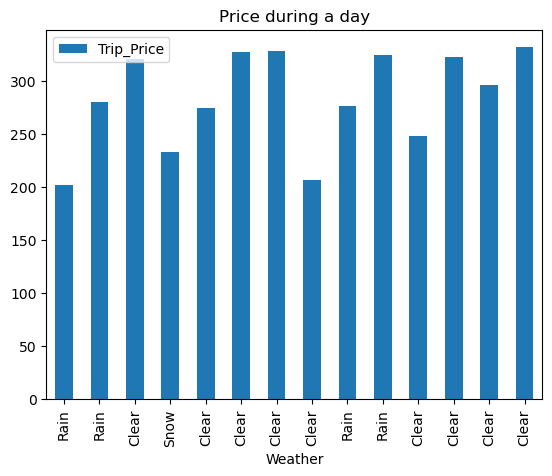

In [144]:
pricy.plot(kind='bar', x='Weather', y='Trip_Price', title='Price during a day')
plt.show()

<Axes: xlabel='Day_of_Week'>

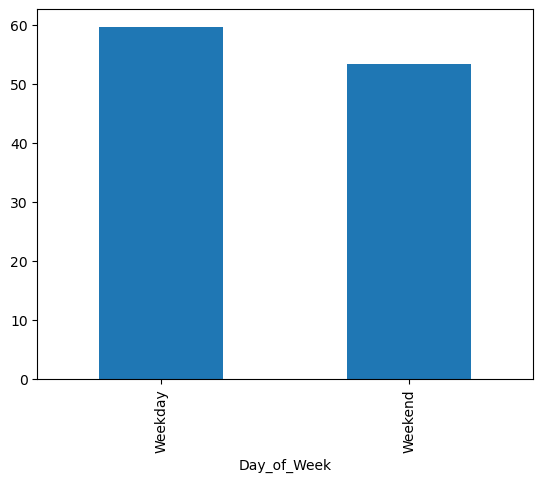

In [142]:
ccleaned.groupby('Day_of_Week')['Trip_Price'].mean().plot(kind='bar')